# Assignment 3: Building PCA from Scratch — Step by Step

This one was challenging but genuinely useful. The instructions said no sklearn — I had to write every step manually using only NumPy. The dataset is a real manufacturing sensor dataset with 100,000 rows and 9 features.

Honestly, doing it the hard way made me understand what PCA actually does at each step, rather than just calling `pca.fit_transform()` and trusting the output.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import csv

DATA_PATH = '../data/manufacturing_6G_dataset.csv'

# Load CSV manually (no pandas, no sklearn)
with open(DATA_PATH, newline='') as f:
    reader = csv.DictReader(f)
    rows = list(reader)

# Numeric feature columns only — drop Timestamp, Machine_ID, Operation_Mode, Efficiency_Status
FEATURES = [
    'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
    'Network_Latency_ms', 'Packet_Loss_%', 'Quality_Control_Defect_Rate_%',
    'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score', 'Error_Rate_%'
]

X_raw = np.array([[float(row[f]) for f in FEATURES] for row in rows])

print(f"Dataset shape : {X_raw.shape}")
print(f"Features      : {FEATURES}")

Dataset shape : (100000, 9)
Features      : ['Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW', 'Network_Latency_ms', 'Packet_Loss_%', 'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score', 'Error_Rate_%']


## Step 1: Standardize the Data

Before anything else, I need to standardize the features. The dataset has features like Production_Speed (400 units/hr) and Packet_Loss (1%), which are on completely different scales. If I skip this step, PCA would just latch onto the features with the biggest numbers and ignore the rest — which would be meaningless.

Z-score standardization: subtract the mean and divide by std. After this, every feature has mean 0 and std 1.

In [10]:
mean = X_raw.mean(axis=0)       # shape: (9,)
std  = X_raw.std(axis=0, ddof=1)  # sample std, shape: (9,)

X = (X_raw - mean) / std        # standardized data, shape: (100000, 9)

print("After standardization:")
print(f"  Mean (should be ~0): {X.mean(axis=0).round(4)}")
print(f"  Std  (should be ~1): {X.std(axis=0, ddof=1).round(4)}")

After standardization:
  Mean (should be ~0): [ 0.  0. -0.  0.  0. -0. -0.  0.  0.]
  Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Step 2: Build the Covariance Matrix

Now I compute the covariance matrix — a 9×9 matrix that tells me how each pair of features varies together. Since I already centered the data in Step 1, I can compute it with a matrix multiplication: `C = X^T @ X / (n-1)`.

I am also plotting it as a heatmap so I can visually spot which features are correlated with each other.

Covariance matrix shape: (9, 9)

Covariance Matrix (rounded to 3 dp):
[[ 1.     0.001  0.005 -0.002  0.003 -0.002  0.001 -0.002 -0.002]
 [ 0.001  1.     0.005  0.008  0.     0.    -0.001  0.004  0.005]
 [ 0.005  0.005  1.    -0.003 -0.001 -0.001  0.002  0.002  0.001]
 [-0.002  0.008 -0.003  1.    -0.007 -0.004 -0.001 -0.003  0.   ]
 [ 0.003  0.    -0.001 -0.007  1.    -0.005 -0.007  0.001 -0.002]
 [-0.002  0.    -0.001 -0.004 -0.005  1.    -0.005 -0.    -0.001]
 [ 0.001 -0.001  0.002 -0.001 -0.007 -0.005  1.     0.004  0.006]
 [-0.002  0.004  0.002 -0.003  0.001 -0.     0.004  1.     0.005]
 [-0.002  0.005  0.001  0.    -0.002 -0.001  0.006  0.005  1.   ]]


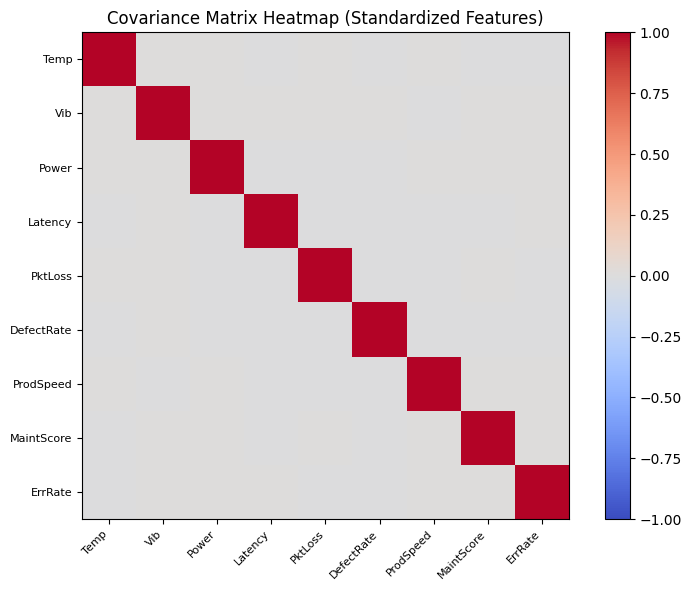

In [18]:
n = X.shape[0]
C = (X.T @ X) / (n - 1)   # shape: (9, 9)

print(f"Covariance matrix shape: {C.shape}")
print("\nCovariance Matrix (rounded to 3 dp):")
print(np.round(C, 3))

# Visualize as heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(C, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(FEATURES)))
ax.set_yticks(range(len(FEATURES)))
short = ['Temp', 'Vib', 'Power', 'Latency', 'PktLoss', 'DefectRate', 'ProdSpeed', 'MaintScore', 'ErrRate']
ax.set_xticklabels(short, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(short, fontsize=8)
ax.set_title('Covariance Matrix Heatmap (Standardized Features)')
plt.tight_layout()
plt.savefig('../output/pca_assignment_3_covariance.png', dpi=150)
plt.show()

## Step 3: Eigendecomposition

This is where the magic happens. I decompose the covariance matrix into eigenvalues and eigenvectors. Each eigenvector is a potential new axis, and its eigenvalue tells me how much variance lies along that axis.

In [19]:
eigenvalues, eigenvectors = np.linalg.eig(C)

# Keep only real parts (covariance matrix is symmetric so imaginary parts are numerical noise)
eigenvalues  = eigenvalues.real
eigenvectors = eigenvectors.real

print("Eigenvalues (unsorted):")
for i, val in enumerate(eigenvalues):
    print(f"  Lambda{i+1} = {val:.4f}")

Eigenvalues (unsorted):
  Lambda1 = 0.9834
  Lambda2 = 0.9882
  Lambda3 = 0.9935
  Lambda4 = 0.9948
  Lambda5 = 1.0152
  Lambda6 = 1.0101
  Lambda7 = 1.0032
  Lambda8 = 1.0068
  Lambda9 = 1.0048


## Step 4: Sort by Importance (Largest Eigenvalue First)

The eigenvalues come out in no particular order, so I sort them from largest to smallest. This puts PC1 first (most variance), then PC2, and so on. I also generate a scree plot to visualise how much each component contributes.

PC      Eigenvalue   Explained %  Cumulative %
----------------------------------------------
PC1         1.0152        11.28%        11.28%
PC2         1.0101        11.22%        22.50%
PC3         1.0068        11.19%        33.69%
PC4         1.0048        11.16%        44.85%
PC5         1.0032        11.15%        56.00%
PC6         0.9948        11.05%        67.05%
PC7         0.9935        11.04%        78.09%
PC8         0.9882        10.98%        89.07%
PC9         0.9834        10.93%       100.00%


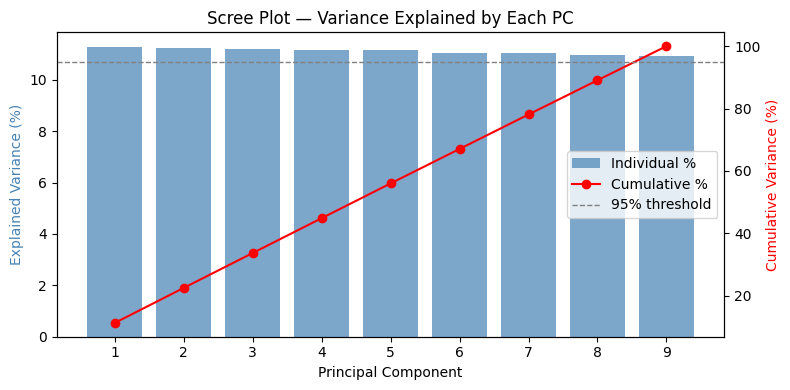

In [20]:
order        = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order]
eigenvectors = eigenvectors[:, order]   # each column is one eigenvector

total_var            = eigenvalues.sum()
explained_var_ratio  = eigenvalues / total_var
cumulative_var_ratio = np.cumsum(explained_var_ratio)

print(f"{'PC':<5} {'Eigenvalue':>12} {'Explained %':>13} {'Cumulative %':>13}")
print("-" * 46)
for i in range(len(eigenvalues)):
    print(f"PC{i+1:<3} {eigenvalues[i]:>12.4f} {explained_var_ratio[i]*100:>12.2f}% {cumulative_var_ratio[i]*100:>12.2f}%")

# Scree plot
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.bar(range(1, len(eigenvalues)+1), explained_var_ratio * 100, color='steelblue', alpha=0.7, label='Individual %')
ax2.plot(range(1, len(eigenvalues)+1), cumulative_var_ratio * 100, 'ro-', label='Cumulative %')
ax2.axhline(95, color='gray', ls='--', lw=1, label='95% threshold')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)', color='steelblue')
ax2.set_ylabel('Cumulative Variance (%)', color='red')
ax1.set_title('Scree Plot — Variance Explained by Each PC')
ax1.set_xticks(range(1, len(eigenvalues)+1))
fig.legend(loc='center right', bbox_to_anchor=(1, 0.5), bbox_transform=ax1.transAxes)
plt.tight_layout()
plt.savefig('../output/pca_assignment_3_scree.png', dpi=150)
plt.show()

## Step 5: Choose How Many Components to Keep

I am keeping k = 8 components out of 9, which means I am dropping just the one least informative direction. The projection matrix W (shape 9×8) is just the top-8 eigenvectors stacked as columns.

In [21]:
k = 8

print(f"Selected k = {k} components")
print(f"Variance captured by top {k} PCs: {cumulative_var_ratio[k-1]*100:.2f}%")
print(f"Variance dropped (PC{k+1}): {explained_var_ratio[k]*100:.2f}%")

# Projection matrix W: shape (9, 8)
W = eigenvectors[:, :k]
print(f"\nProjection matrix W shape: {W.shape}  (features x k)")

Selected k = 8 components
Variance captured by top 8 PCs: 89.07%
Variance dropped (PC9): 10.93%

Projection matrix W shape: (9, 8)  (features x k)


## Step 6: Project the Data into the New Space

The final step — multiply the standardized data by W. This transforms each 9-dimensional point into an 8-dimensional point in the PCA space. I will also verify that the variance of each PC matches its eigenvalue, just to confirm everything is correct.

In [22]:
X_pca = X @ W    # shape: (100000, k)

print(f"Original data shape  : {X.shape}")
print(f"Projected data shape : {X_pca.shape}")
print(f"\nDimensionality reduced from {X.shape[1]} → {k} components")

# Verify: variance of each PC should equal its eigenvalue
print("\nVerification — Var(PC_i) vs Lambda_i:")
for i in range(k):
    var_pc = np.var(X_pca[:, i], ddof=1)
    print(f"  PC{i+1}: Var = {var_pc:.4f}  |  Lambda{i+1} = {eigenvalues[i]:.4f}  |  Match: {np.isclose(var_pc, eigenvalues[i], atol=0.01)}")

Original data shape  : (100000, 9)
Projected data shape : (100000, 8)

Dimensionality reduced from 9 → 8 components

Verification — Var(PC_i) vs Lambda_i:
  PC1: Var = 1.0152  |  Lambda1 = 1.0152  |  Match: True
  PC2: Var = 1.0101  |  Lambda2 = 1.0101  |  Match: True
  PC3: Var = 1.0068  |  Lambda3 = 1.0068  |  Match: True
  PC4: Var = 1.0048  |  Lambda4 = 1.0048  |  Match: True
  PC5: Var = 1.0032  |  Lambda5 = 1.0032  |  Match: True
  PC6: Var = 0.9948  |  Lambda6 = 0.9948  |  Match: True
  PC7: Var = 0.9935  |  Lambda7 = 0.9935  |  Match: True
  PC8: Var = 0.9882  |  Lambda8 = 0.9882  |  Match: True


## Bonus: Visualizing the Projection

I wanted to see whether PCA had actually found any meaningful structure in this dataset. So I plotted PC1 vs PC2 and colored each point by its Operation_Mode. If the modes cluster separately, it means PCA captured something real — not just noise.

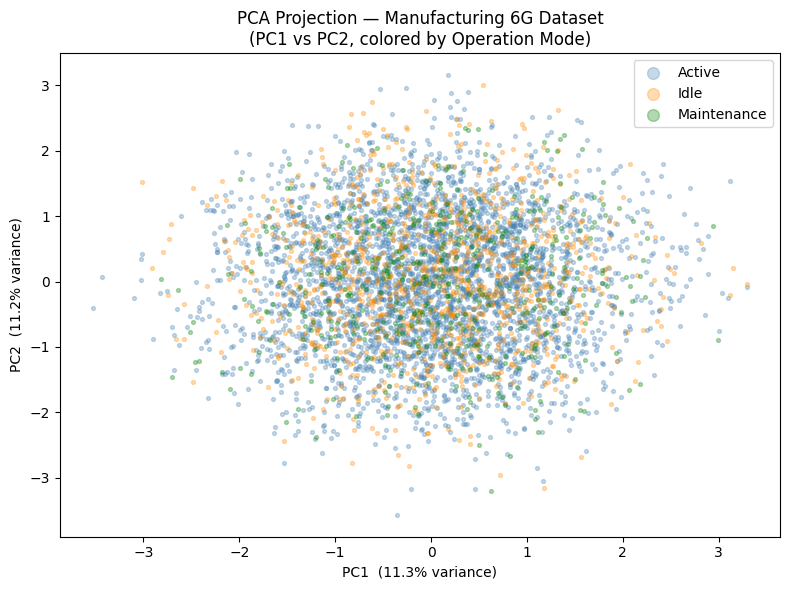

In [23]:
modes        = np.array([row['Operation_Mode'] for row in rows])
unique_modes = np.unique(modes)
colors_map   = {'Active': 'steelblue', 'Idle': 'darkorange', 'Maintenance': 'green'}

# Plot PC1 vs PC2 (subsample 5000 points for readability)
idx = np.random.choice(len(X_pca), size=5000, replace=False)

fig, ax = plt.subplots(figsize=(8, 6))
for mode in unique_modes:
    mask = modes[idx] == mode
    ax.scatter(X_pca[idx][mask, 0], X_pca[idx][mask, 1],
               alpha=0.3, s=8, label=mode, color=colors_map.get(mode, 'gray'))

ax.set_xlabel(f'PC1  ({explained_var_ratio[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2  ({explained_var_ratio[1]*100:.1f}% variance)')
ax.set_title('PCA Projection — Manufacturing 6G Dataset\n(PC1 vs PC2, colored by Operation Mode)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../output/pca_assignment_3_projection.png', dpi=150)
plt.show()